# 🤖 LangGraph Examples - 4: Loops in a Graph

**Author:** *José Ignacio Orlando, PhD*

In this fourth example, we're going to explore one of the most powerful features of LangGraph: **looping edges**. Unlike our previous examples that followed linear or conditional paths, loops allow us to repeat certain operations until a specific condition is met.

Our example will simulate a Chinese restaurant fortune cookie experience, where we keep drawing fortune cookies until we get one that doesn't contain any "bad" words. This demonstrates how loops can be used to iterate until a satisfactory result is achieved.

## Step 1 - Define the agent state

For this looping workflow, we need to define a state that can track:

1. **name**: The user's name for personalization
2. **cookies**: A bag of fortune messages to sample from
3. **history**: A log of all actions taken (useful for debugging and understanding the flow)
4. **fortune**: The current fortune that was drawn
5. **disliked_substrings**: Words we want to avoid in our fortunes

Notice that we're using `total=False` again, which gives us flexibility in how we initialize the state. This is particularly useful for looping scenarios where we might want to start with minimal information and build up the state as we iterate.

In [1]:
from typing import TypedDict, List

class State(TypedDict, total=False):
    name: str # name of the user
    cookies: List[str]  # bag of fortunes to sample from
    history: List[str] # keep all fortunes we saw (for teaching/debugging)
    fortune: str # the fortune we drew
    disliked_substrings: List[str] # the substrings we dislike

## Step 2 - Define the nodes

Now we'll define three different types of nodes that work together to create our looping fortune cookie experience:

* **Node 1: `greeting_node`** - This node welcomes the user to our virtual Chinese restaurant. It's a simple initialization node that sets up the conversation and initializes our history log.

* **Node 2: `draw_cookie`** - This is our main working node that simulates drawing a fortune cookie. It randomly selects a fortune from our bag, removes it (so we don't get duplicates), and logs the action. This node will be executed multiple times if we need to loop.

* **Node 3: `judge_cookie`** - This is our **conditional node** that decides whether to continue looping or exit. It examines the current fortune and checks if it contains any of our disliked substrings. If it finds any "bad" words, it returns "loop" to continue drawing cookies. If the fortune is acceptable, it returns "exit" to end the process.

The key insight here is that `judge_cookie` doesn't modify the state directly - it only examines it and makes a routing decision. This is the pattern for conditional nodes that control loop behavior.

In [ ]:
import random

# node to welcome to the chinese restaurant
def greeting_node(state: State) -> State:
    """Greeting node that welcomes the user to the chineese restaurant"""
    state["history"] = ["Hi there " + state["name"]]
    return state

# node to draw a cookie
def draw_cookie(state: State) -> State:
    """Pick a random fortune and update counters."""
    # simulate randomly drawing a fortune from the bag
    random.shuffle(state["cookies"]) # shuffle the bag
    state["fortune"] = state["cookies"].pop() # get one element
    state["history"] = state["history"] + ["Cookie: " + state["fortune"]] # add to history
    return state

# node that judges the cookie
def judge_cookie(state: State) -> State:
    """Determine if the cookie is good or bad."""
    # if the fortune contains any of the disliked substrings, loop
    if any(bad.lower() in state["fortune"].lower() for bad in state["disliked_substrings"]):
        return "loop"
    else:
        return "exit"

## Step 3 - Define the execution graph with loops

This is where the looping magic happens! We're going to create a graph that can repeat the cookie-drawing process until we get a satisfactory result.

The workflow we're building follows this sequence:
1. **START** → `greeting` (welcome the user)
2. `greeting` → `draw_cookie` (draw the first fortune)
3. `draw_cookie` → `judge_cookie` (evaluate the fortune)
4. **Loop decision**: 
   - If "loop" → back to `draw_cookie` (try again)
   - If "exit" → **END** (we're satisfied with the fortune)

The crucial part is the `add_conditional_edges()` method, which creates the loop. Notice how we map "loop" back to the same `draw_cookie` node, creating a cycle in our graph. This is what enables the repetition - the graph can revisit the same node multiple times until the condition is met.

This pattern is incredibly powerful for scenarios where you need to:
- Retry operations until success
- Iterate until a quality threshold is met
- Keep trying until user satisfaction
- Implement any kind of iterative refinement process

In [ ]:
from langgraph.graph import StateGraph, START, END

# initialize the graph
graph = StateGraph(State)

# add the nodes
graph.add_node("greeting", greeting_node)
graph.add_node("random_cookie", draw_cookie)

# add the edges
graph.add_edge(START, "greeting")
graph.add_edge("greeting", "random_cookie")

# add the conditional edges
graph.add_conditional_edges(
    "random_cookie",     # source node: the one that gets a random cookie
    judge_cookie,       # action node: the one that judges the cookie
    {
        "loop": "random_cookie",   # if the cookie is bad, loop back to the random cookie node
        "exit": END           # if the cookie is good, end the process
    }
)

# compile the graph
app = graph.compile()

Let's visualize our looping graph to see how the cycle is represented:

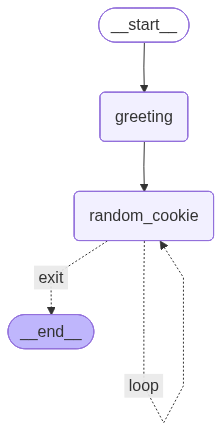

In [4]:
from IPython.display import Image, display
# retrieve the graph, draw the mermaing code, model that as an image, and display it
display(Image(app.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

## Step 4 - Execute!

Time to test our looping fortune cookie system! In this example, we'll see how the graph automatically handles the loop until it finds an acceptable fortune.

The execution will show us:
- How the greeting is processed first
- How the system keeps drawing cookies until it finds one without "bad" words
- The complete history of all actions taken

Notice how the system intelligently avoided fortunes containing "bad", "ugly", or "horrible" and eventually found "Finally the far right will leave the government" - a fortune that doesn't contain any of our disliked substrings.

This demonstrates the power of loops in LangGraph: the system can automatically retry operations, make decisions about when to continue or stop, and maintain state throughout the entire process. This pattern is essential for building robust agents that can handle uncertainty and iterate toward better results.

In [5]:
state = {
    "cookies": ["Something bad will happen to you", "There's something horrible waiting for you", "You're gonna be ruled by a bad president",
                "There's a bad virus that will spread all over the world", "You're gonna be injured and your face will look horrible",
                "Finally the far right will leave the government"],
    "disliked_substrings": ["bad", "ugly", "horrible"],
    "name": "Nacho",
    "history": []
}

result = app.invoke(state)

print(result["history"])

['Hi there Nacho', "Cookie: There's something horrible waiting for you", "Cookie: You're gonna be ruled by a bad president", "Cookie: There's a bad virus that will spread all over the world", 'Cookie: Finally the far right will leave the government']


Perfect! You've now mastered the four fundamental patterns in LangGraph:

- **Sequential execution**: Linear workflows where each step follows the previous one
- **Conditional branching**: Decision points that route execution to different paths
- **Looping**: Iterative processes that repeat until conditions are met
- **State management**: How information flows and accumulates through the graph

These building blocks form the foundation for creating sophisticated AI agents. In the next examples, we'll integrate actual Large Language Models to create truly intelligent systems that can understand, reason, and respond to complex inputs.

The looping pattern you just learned is particularly important for AI applications, where you often need to:
- Refine responses until they meet quality standards
- Retry failed operations with different approaches
- Iterate through multiple options to find the best solution
- Implement conversational flows that continue until user satisfaction

You're now ready to build complex, intelligent agents with LangGraph! 🎉